# Audience Analysis — Kenya

**Norman Lear Center × Gates Foundation — Manfluencer project**

Same pipeline as Nigeria, re-targeted at Kenya content. Six pre-selected posts (3 progressive / 3 regressive) are filtered down to ~200 topically relevant comments each using a four-signal stack: quality filter → Kenya keyword lexicon → `text-embedding-3-large` similarity to scope anchors → `gpt-4o-mini` relevance classification → composite ranking.

## Pipeline

1. Load raw comments across five platforms (X, YouTube, TikTok, Instagram).
2. Drop creator-authored rows (OP + thread continuations) via platform-specific detection (URL for X, `ownerUsername` for IG, `uniqueId` for TikTok, `author` for YouTube).
3. Drop pull-quote comments that just repeat the OP verbatim.
4. Substantiveness filter.
5. Keyword annotation (NLC Kenya lexicon — Swahili, Sheng, Gikuyu).
6. Semantic similarity to anchor phrases.
7. LLM classification (loose relevance, per manager guidance).
8. Composite score + top-200 selection (caps at available if a post has fewer raw).
9. Export to `Topic Relevant Comments - Kenya/<Creator>/<Post>.xlsx` — text column only.
10. Report-ready plots in `Audience Analysis Plots - Kenya/`.


## 0 — Setup

In [1]:
from __future__ import annotations

import asyncio
import json
import os
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from openai import AsyncOpenAI, OpenAI
from tqdm.asyncio import tqdm as atqdm
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
print("Project root:", ROOT)
load_dotenv(ROOT / ".env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not set — add it to .env"
print("OpenAI key loaded:", os.getenv("OPENAI_API_KEY")[:8] + "…")


Project root: /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project
OpenAI key loaded: sk-proj-…


## 1 — Config (6 selected Kenya posts)

In [2]:
INPUT_DIR = ROOT / "Kenya Audience Comments"
KEYWORDS_XLSX = ROOT / "Codebook and Keywords" / "NLC Proposed keywords.xlsx"
OUTPUT_DIR = ROOT / "Topic Relevant Comments - Kenya"
TEMP_DIR = ROOT / "temp" / "audience_analysis_kenya"
PLOTS_DIR = ROOT / "Audience Analysis Plots - Kenya"

TEMP_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL = "text-embedding-3-large"
LLM_MODEL = "gpt-4o-mini"
TARGET_PER_POST = 200
LLM_BATCH_SIZE = 20
LLM_CONCURRENCY = 16
EMBED_BATCH_SIZE = 256

SELECTED_POSTS = [
    # Regressive
    {"creator": "Amerix",          "orientation": "Regressive",  "post": "Stay Away From Vulgar Women",
     "file": "Full Tweet Stay away from vulgar women.xlsx",                 "text_col": "text",    "platform": "x",        "creator_handle": "amerix"},
    {"creator": "Amerix",          "orientation": "Regressive",  "post": "A Woman Can't Love a Man",
     "file": "Tweet_A woman can't love a man. It is a man who loves a woman..xlsx", "text_col": "text", "platform": "x",    "creator_handle": "ionexiss"},
    {"creator": "Andrew Kibe",     "orientation": "Regressive",  "post": "I Wonder How Some Men Are Satisfied",
     "file": "Tweet; I wonder how some men are satisfied with just one woman... .xlsx", "text_col": "text", "platform": "x", "creator_handle": "kibeandy"},
    # Progressive
    {"creator": "Philip Karanja",  "orientation": "Progressive", "post": "Girl Dad Episode 1",
     "file": "Youtube- Episode 1- A Girl Dad on a Mission .xlsx",            "text_col": "comment", "platform": "youtube",  "creator_handle": "@philkaranja"},
    {"creator": "Onyango Otieno",  "orientation": "Progressive", "post": "My Voice Was Beaten Out of Me",
     "file": "Youtube-My voice was beaten out of me by my father - Toxic masculinity .xlsx", "text_col": "comment", "platform": "youtube", "creator_handle": "@Rixpoet"},
    {"creator": "Eddy Kimani",     "orientation": "Progressive", "post": "Young Man Thinks It's A Shame Not Having A Car At 35",
     "file": "Tiktok; Young man who thinks it's a shame not having a car at 35.xlsx", "text_col": "text",    "platform": "tiktok",  "creator_handle": "eddykimani"},
]

print(f"{len(SELECTED_POSTS)} posts selected — 3 Progressive, 3 Regressive, 5 creators covered")
for p in SELECTED_POSTS:
    print(f"  • {p['creator']:<18} [{p['orientation']:<12}] [{p['platform']:<7}] {p['post']}")


6 posts selected — 3 Progressive, 3 Regressive, 5 creators covered
  • Amerix             [Regressive  ] [x      ] Stay Away From Vulgar Women
  • Amerix             [Regressive  ] [x      ] A Woman Can't Love a Man
  • Andrew Kibe        [Regressive  ] [x      ] I Wonder How Some Men Are Satisfied
  • Philip Karanja     [Progressive ] [youtube] Girl Dad Episode 1
  • Onyango Otieno     [Progressive ] [youtube] My Voice Was Beaten Out of Me
  • Eddy Kimani        [Progressive ] [tiktok ] Young Man Thinks It's A Shame Not Having A Car At 35


## 2 — Load raw comments (platform-aware OP detection)

In [3]:
URL_HANDLE_PATTERNS = [
    re.compile(r"x\.com/(?P<h>[A-Za-z0-9_]+)/status", re.IGNORECASE),
    re.compile(r"twitter\.com/(?P<h>[A-Za-z0-9_]+)/status", re.IGNORECASE),
]


def _normalize_text(s):
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\u201c", '"').replace("\u201d", '"')
    s = s.replace("\u2018", "'").replace("\u2019", "'")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def _strip_leading_handle(text, handle):
    if not handle or not isinstance(text, str):
        return text
    h = handle.lstrip("@")
    pattern = re.compile(rf"^\s*@{re.escape(h)}\b[\s:,.-]*", flags=re.IGNORECASE)
    return pattern.sub("", text).strip()


def _norm_for_ngram(t):
    t = str(t).lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


def _ngrams(t, n=8):
    toks = t.split()
    return {" ".join(toks[i:i + n]) for i in range(len(toks) - n + 1)} if len(toks) >= n else {t}


def _is_op_row(row, meta):
    handle = meta["creator_handle"].lstrip("@").lower()
    platform = meta["platform"]
    if platform == "youtube":
        author = str(row.get("author", "")).lstrip("@").lower()
        return author == handle
    if platform == "instagram":
        owner = str(row.get("ownerUsername", "")).lstrip("@").lower()
        return owner == handle
    if platform == "tiktok":
        uid = str(row.get("uniqueId", "")).lstrip("@").lower()
        return uid == handle
    if platform == "x":
        for url_field in ("url", "twitterUrl", "pageUrl"):
            u = row.get(url_field)
            if not isinstance(u, str):
                continue
            for pat in URL_HANDLE_PATTERNS:
                m = pat.search(u)
                if m and m.group("h").lower() == handle:
                    return True
        return False
    return False


def load_post(meta):
    path = INPUT_DIR / meta["file"]
    df = pd.read_excel(path)

    op_mask = df.apply(lambda r: _is_op_row(r, meta), axis=1)
    dropped_op = int(op_mask.sum())
    op_ngrams = set()
    for t in df.loc[op_mask, meta["text_col"]].astype(str):
        op_ngrams |= _ngrams(_norm_for_ngram(t))
    df = df.loc[~op_mask].reset_index(drop=True)

    df["raw_text"] = df[meta["text_col"]].apply(_normalize_text)
    df["raw_text"] = df["raw_text"].apply(lambda t: _strip_leading_handle(t, meta["creator_handle"]))

    # Drop pull-quote comments that copy the OP verbatim
    dropped_quotes = 0
    if op_ngrams:
        def is_quote(t):
            ng = _ngrams(_norm_for_ngram(t))
            if not ng:
                return False
            overlap = len(ng & op_ngrams) / len(ng)
            return overlap >= 0.5 and len(_norm_for_ngram(t).split()) >= 8
        q_mask = df["raw_text"].apply(is_quote)
        dropped_quotes = int(q_mask.sum())
        df = df.loc[~q_mask].reset_index(drop=True)

    # Drop exact-text duplicates (some scrapes repeat the same comment)
    dropped_dups = int(df["raw_text"].duplicated().sum())
    if dropped_dups:
        df = df.drop_duplicates(subset="raw_text").reset_index(drop=True)

    df["creator"] = meta["creator"]
    df["orientation"] = meta["orientation"]
    df["post"] = meta["post"]
    df["platform"] = meta["platform"]

    keep = ["creator", "orientation", "post", "platform", "raw_text"]
    for aux in ("author", "ownerUsername", "uniqueId", "likes", "replies", "retweets",
                "reply_count", "diggCount", "replyCommentTotal", "voteCount", "timestamp",
                "createTimeISO", "createdAt", "url", "videoWebUrl", "pageUrl", "postUrl"):
        if aux in df.columns:
            keep.append(aux)

    if dropped_op or dropped_quotes or dropped_dups:
        print(f"  · {meta['creator']} :: {meta['post']}: dropped {dropped_op} creator + {dropped_quotes} pull-quote + {dropped_dups} dup rows")
    return df[keep]


raw_frames = [load_post(p) for p in SELECTED_POSTS]
raw = pd.concat(raw_frames, ignore_index=True)
raw_counts = raw.groupby(["creator", "post"]).size().reset_index(name="raw_n")
print(f"Total raw comments across 6 posts (after OP + pull-quote removal): {len(raw):,}")
raw_counts


  · Amerix :: Stay Away From Vulgar Women: dropped 1 creator + 1 pull-quote + 72 dup rows
  · Amerix :: A Woman Can't Love a Man: dropped 1 creator + 1 pull-quote + 8 dup rows
  · Andrew Kibe :: I Wonder How Some Men Are Satisfied: dropped 1 creator + 0 pull-quote + 2 dup rows
  · Philip Karanja :: Girl Dad Episode 1: dropped 0 creator + 0 pull-quote + 2 dup rows


  · Onyango Otieno :: My Voice Was Beaten Out of Me: dropped 2 creator + 0 pull-quote + 1 dup rows


  · Eddy Kimani :: Young Man Thinks It's A Shame Not Having A Car At 35: dropped 2 creator + 0 pull-quote + 128 dup rows
Total raw comments across 6 posts (after OP + pull-quote removal): 3,481


,creator,post,raw_n
0,Amerix,A Woman Can't Love a Man,338
1,Amerix,Stay Away From Vulgar Women,784
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,164
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,1788
4,Onyango Otieno,My Voice Was Beaten Out of Me,223
5,Philip Karanja,Girl Dad Episode 1,184


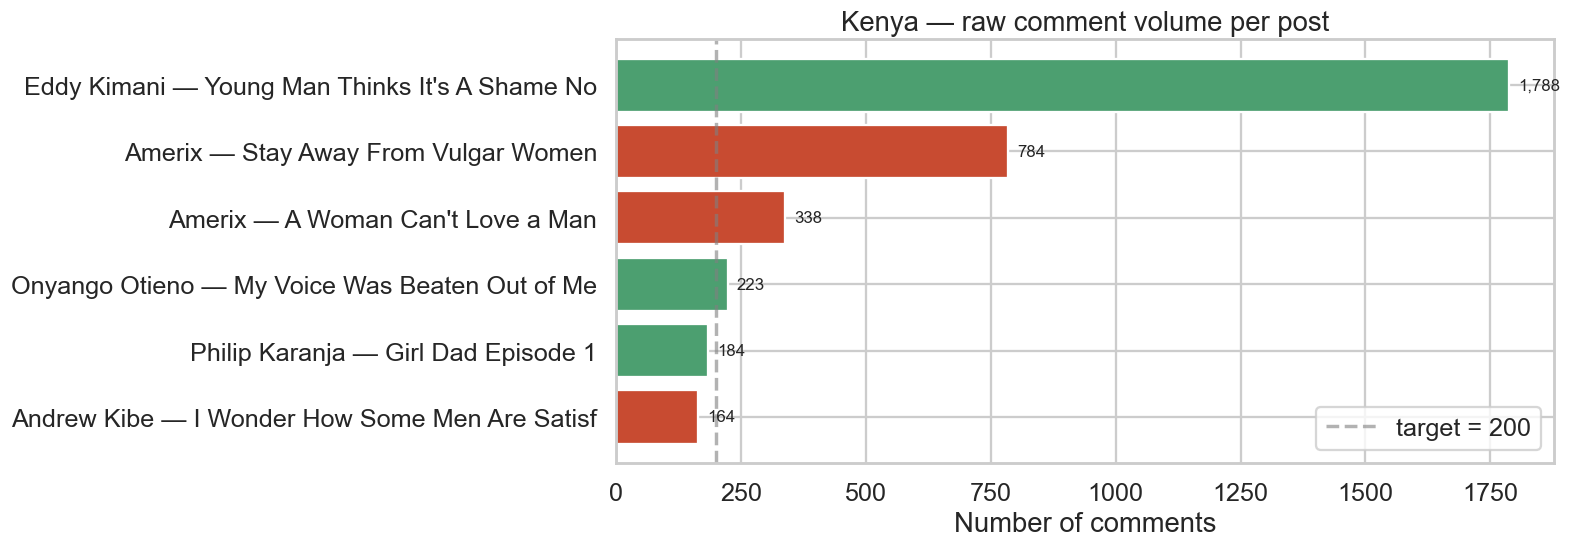

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
order = raw_counts.merge(
    raw.drop_duplicates(["creator", "post"])[["creator", "post", "orientation"]],
    on=["creator", "post"]).sort_values("raw_n", ascending=True)
bars = ax.barh(order["creator"] + " — " + order["post"].str.slice(0, 32), order["raw_n"],
               color=["#4C9F70" if o == "Progressive" else "#C84B31" for o in order["orientation"]])
ax.axvline(200, linestyle="--", color="grey", alpha=0.6, label="target = 200")
ax.set_title("Kenya — raw comment volume per post")
ax.set_xlabel("Number of comments")
for bar, n in zip(bars, order["raw_n"]):
    ax.text(bar.get_width() + max(order["raw_n"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{n:,}", va="center", fontsize=11)
ax.legend()
plt.savefig(PLOTS_DIR / "01_raw_volume.png")
plt.show()


## 3 — Basic quality filter

In [5]:
EMOJI_PATTERN = re.compile(
    "[\U0001F300-\U0001FAFF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF"
    "\U00002600-\U000027BF\U0001F900-\U0001F9FF\U00002700-\U000027BF"
    "\U0001F100-\U0001F1FF]+", flags=re.UNICODE)
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+|\S+\.(com|co|ke|org|io)/\S*", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"@\w+")


def strip_decorations(s):
    s = URL_PATTERN.sub(" ", s)
    s = MENTION_PATTERN.sub(" ", s)
    s = EMOJI_PATTERN.sub(" ", s)
    return re.sub(r"\s+", " ", s).strip()


def quality_signals(text):
    stripped = strip_decorations(text)
    words = re.findall(r"[A-Za-z']+", stripped)
    return pd.Series({
        "stripped_text": stripped,
        "n_words": len(words),
        "n_alpha_words": sum(1 for w in words if any(c.isalpha() for c in w)),
        "longest_word_len": max((len(w) for w in words), default=0),
        "stripped_chars": len(stripped),
    })


def is_substantive(row):
    return (row["stripped_chars"] >= 8 and row["n_words"] >= 3
            and row["n_alpha_words"] >= 2 and row["longest_word_len"] >= 3)


signals = raw["raw_text"].apply(quality_signals)
df = pd.concat([raw, signals], axis=1)
df["is_substantive"] = df.apply(is_substantive, axis=1)

retention = (df.groupby(["creator", "post"])
               .agg(raw=("raw_text", "count"), substantive=("is_substantive", "sum"))
               .reset_index())
retention["retention_rate"] = retention["substantive"] / retention["raw"]
print(f"Substantive comments: {int(df['is_substantive'].sum()):,} / {len(df):,} ({df['is_substantive'].mean():.1%})")
retention


Substantive comments: 2,865 / 3,481 (82.3%)


,creator,post,raw,substantive,retention_rate
0,Amerix,A Woman Can't Love a Man,338,257,0.760355
1,Amerix,Stay Away From Vulgar Women,784,666,0.849490
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,164,146,0.890244
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,1788,1438,0.804251
4,Onyango Otieno,My Voice Was Beaten Out of Me,223,200,0.896861
5,Philip Karanja,Girl Dad Episode 1,184,158,0.858696


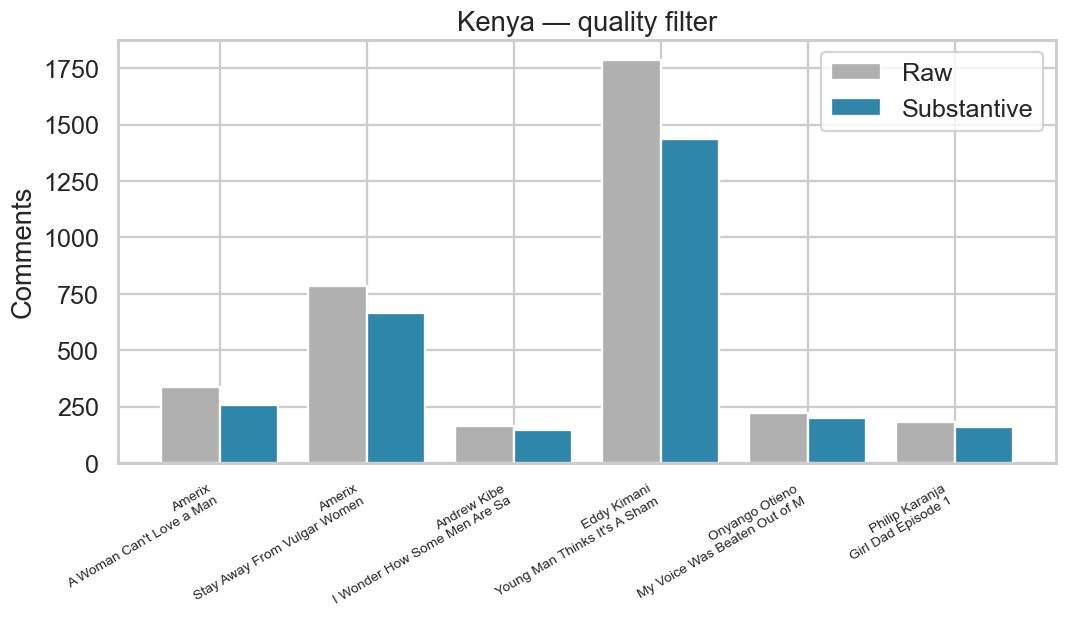

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(retention))
w = 0.4
labels = retention["creator"] + "\n" + retention["post"].str.slice(0, 28)
ax.bar(x - w/2, retention["raw"], w, label="Raw", color="#B0B0B0")
ax.bar(x + w/2, retention["substantive"], w, label="Substantive", color="#2E86AB")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Comments")
ax.set_title("Kenya — quality filter")
ax.legend()
plt.savefig(PLOTS_DIR / "02_quality_filter.png")
plt.show()


## 4 — Keyword annotation (NLC Kenya lexicon)

In [7]:
kw_df = pd.read_excel(KEYWORDS_XLSX, sheet_name="Kenya")
kw_df = kw_df.dropna(subset=["Keyword"])
kw_df["Keyword"] = kw_df["Keyword"].astype(str).str.strip()
kw_df = kw_df[kw_df["Keyword"].str.len() >= 2]

rel_col = "Relevance to masculinity conversations"
kw_highly = set(kw_df.loc[kw_df[rel_col].astype(str).str.contains("Highly", na=False), "Keyword"].str.lower())
kw_moderate = set(kw_df.loc[kw_df[rel_col].astype(str).str.contains("Moderately", na=False), "Keyword"].str.lower())
print(f"Kenya lexicon: {len(kw_df)} terms ({len(kw_highly)} highly, {len(kw_moderate)} moderately relevant)")

all_kws = sorted(kw_highly | kw_moderate, key=len, reverse=True)
kw_regex = re.compile(r"\b(" + "|".join(re.escape(k) for k in all_kws) + r")\b", flags=re.IGNORECASE) if all_kws else None


def kw_hits(text):
    if not kw_regex or not text:
        return []
    return list(dict.fromkeys(kw_regex.findall(text.lower())))


df["keyword_hits"] = df["raw_text"].apply(kw_hits)
df["has_keyword"] = df["keyword_hits"].str.len() > 0
kw_summary = (df[df["is_substantive"]].groupby(["creator", "post"])
              .agg(substantive=("is_substantive", "sum"), with_keyword=("has_keyword", "sum"))
              .reset_index())
kw_summary["keyword_rate"] = kw_summary["with_keyword"] / kw_summary["substantive"]
kw_summary


Kenya lexicon: 295 terms (179 highly, 86 moderately relevant)


,creator,post,substantive,with_keyword,keyword_rate
0,Amerix,A Woman Can't Love a Man,257,92,0.357977
1,Amerix,Stay Away From Vulgar Women,666,118,0.177177
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,146,34,0.232877
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,1438,163,0.113352
4,Onyango Otieno,My Voice Was Beaten Out of Me,200,68,0.340000
5,Philip Karanja,Girl Dad Episode 1,158,44,0.278481


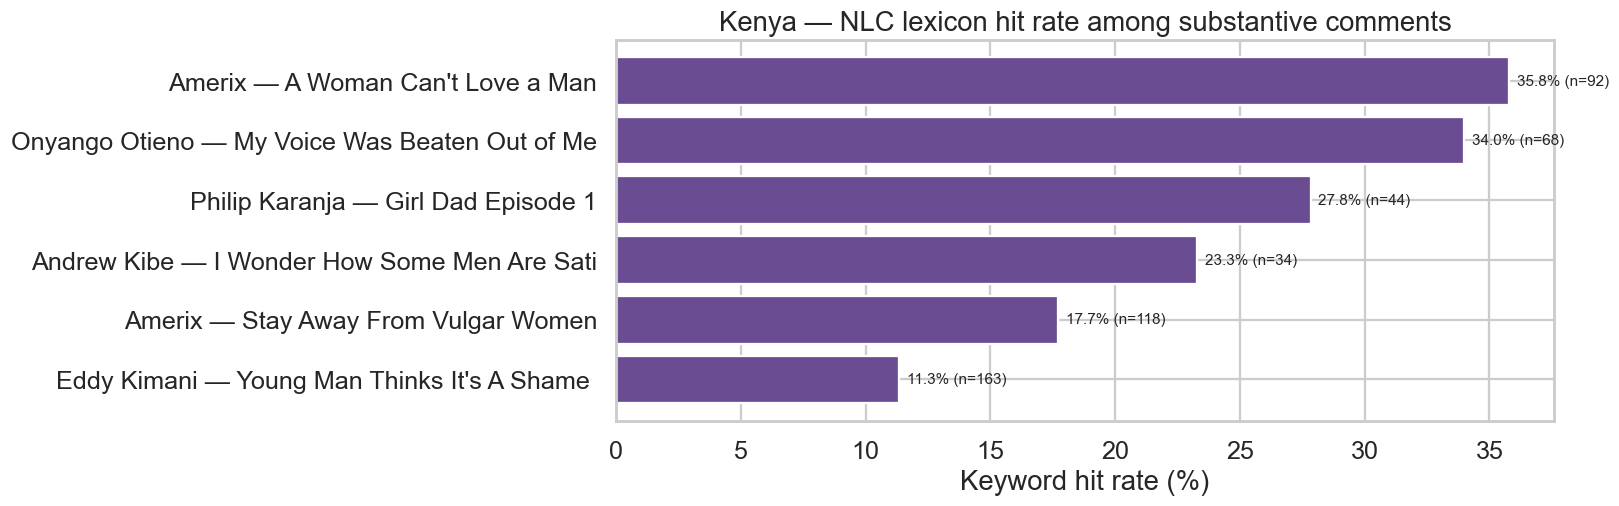

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
o = kw_summary.sort_values("keyword_rate", ascending=True)
ax.barh(o["creator"] + " — " + o["post"].str.slice(0, 30), o["keyword_rate"] * 100, color="#6A4C93")
ax.set_xlabel("Keyword hit rate (%)")
ax.set_title("Kenya — NLC lexicon hit rate among substantive comments")
for i, (r, n) in enumerate(zip(o["keyword_rate"], o["with_keyword"])):
    ax.text(r * 100 + 0.3, i, f"{r:.1%} (n={int(n)})", va="center", fontsize=10)
plt.savefig(PLOTS_DIR / "03_keyword_rate.png")
plt.show()


## 5 — Semantic relevance (OpenAI embeddings)

In [9]:
ANCHORS = [
    "views on what it means to be a man",
    "gender roles and masculinity",
    "traditional masculinity and providing for family",
    "progressive masculinity and emotional vulnerability",
    "marriage, infidelity and fidelity",
    "dating standards and expectations between men and women",
    "polygamy, male scarcity and provider anxiety",
    "female body, sexuality and respectability",
    "rape, sexual violence and accountability",
    "abuse of boys and male victimhood",
    "feminism, misogyny and women's rights in Kenya",
    "faith, partnership and gender in Kenyan culture",
    "agreement with the creator or their message",
    "disagreement or pushback against the creator",
    "personal testimony or life story",
    "advice to young men or young women",
    "money, status and being a provider",
    "fatherhood, raising girls and protecting daughters",
]

client = OpenAI()

def embed_batch(texts, model=EMBEDDING_MODEL):
    resp = client.embeddings.create(model=model, input=list(texts))
    return np.array([d.embedding for d in resp.data])

anchor_emb = embed_batch(ANCHORS)
anchor_emb = anchor_emb / np.linalg.norm(anchor_emb, axis=1, keepdims=True)
print("Anchor embeddings:", anchor_emb.shape)


Anchor embeddings: (18, 3072)


In [10]:
sub = df[df["is_substantive"]].copy().reset_index(drop=True)

embeds_path = TEMP_DIR / "comment_embeddings.npy"
if embeds_path.exists() and len(np.load(embeds_path)) == len(sub):
    emb = np.load(embeds_path)
    print(f"Loaded cached embeddings: {emb.shape}")
else:
    chunks = []
    for start in tqdm(range(0, len(sub), EMBED_BATCH_SIZE), desc="embedding"):
        chunks.append(embed_batch(sub["stripped_text"].iloc[start:start + EMBED_BATCH_SIZE].tolist()))
    emb = np.vstack(chunks)
    np.save(embeds_path, emb)
    print("Embeddings:", emb.shape)

emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
sim = emb_norm @ anchor_emb.T
sub["sim_max"] = sim.max(axis=1)
sub["sim_top_anchor"] = [ANCHORS[i] for i in sim.argmax(axis=1)]
sub[["creator", "post", "stripped_text", "sim_max", "sim_top_anchor"]].head()


embedding:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings: (2865, 3072)


,creator,post,stripped_text,sim_max,sim_top_anchor
0,Amerix,Stay Away From Vulgar Women,I took your advice on this. Divorced my wife o...,0.205926,advice to young men or young women
1,Amerix,Stay Away From Vulgar Women,Vagina is actually the medical term for that p...,0.224237,"female body, sexuality and respectability"
2,Amerix,Stay Away From Vulgar Women,"Vagina is vulgar? I'm a GYN, what am I suppose...",0.288192,"female body, sexuality and respectability"
3,Amerix,Stay Away From Vulgar Women,Good advice from a man no woman wants to fuck.,0.377287,advice to young men or young women
4,Amerix,Stay Away From Vulgar Women,Living my best life,0.271319,personal testimony or life story


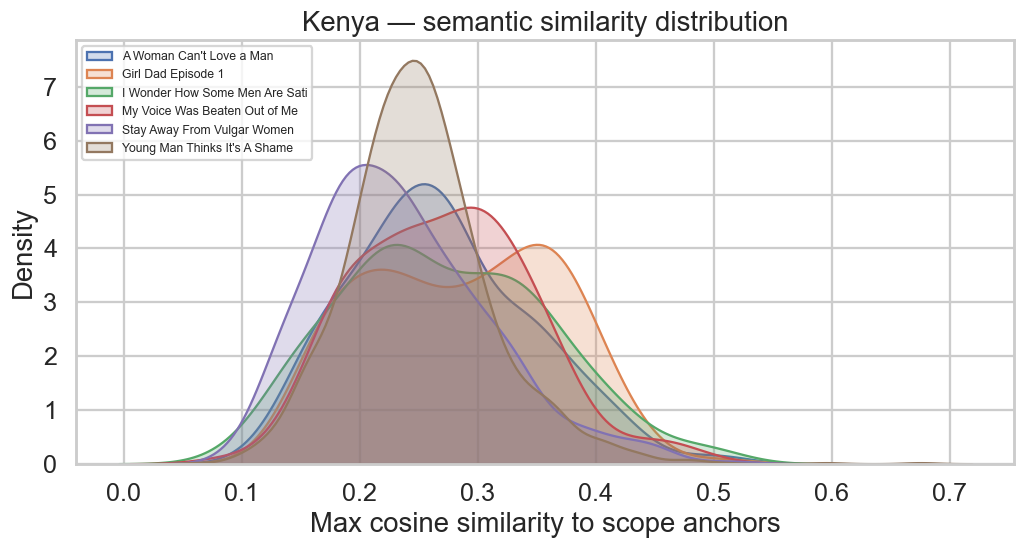

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for post, g in sub.groupby("post"):
    sns.kdeplot(g["sim_max"], ax=ax, label=post[:30], fill=True, alpha=0.25)
ax.set_xlabel("Max cosine similarity to scope anchors")
ax.set_title("Kenya — semantic similarity distribution")
ax.legend(fontsize=8, loc="upper left")
plt.savefig(PLOTS_DIR / "04_similarity_kde.png")
plt.show()


## 6 — LLM relevance classification (GPT-4o-mini)

In [12]:
SYSTEM_PROMPT = '''You are an expert research coder classifying audience comments from Kenyan social media.

A comment is RELEVANT if it is any meaningful engagement with the post's topic or the creator's argument. This includes:
  • Direct discussion of masculinity, gender, relationships, marriage, family, sex, parenting, faith, money, violence, or related themes.
  • Personal testimony or life story prompted by the post.
  • Substantive agreement or disagreement with the creator.
  • Advice offered to men or women in response to the post.
  • Emotional reaction that articulates a reason.

A comment is NOT RELEVANT if it is:
  • Pure emoji, single-word hype, ad/spam, or promotional link.
  • Off-topic chatter about unrelated news, celebrities, or the creator's looks with no substance.
  • Generic praise with zero content ("nice one", "lol").

Be GENEROUS — short substantive reactions like "I totally agree, this changed my life" or "Bitter truth" ARE relevant.
Kenyan audiences frequently mix English, Swahili, Sheng, and Gikuyu; treat non-English phrasing the same way.

Return a JSON object with key "results" whose value is a list of objects:
  {"id": <int>, "relevant": true/false, "reason": "<short reason, 12 words max>"}.
Output nothing else.'''


def build_user_prompt(post_title, orientation, batch):
    lines = [f"Post: {post_title}  |  Creator orientation: {orientation}", "", "Comments:"]
    for i, text in batch:
        safe = text.replace("\n", " ")[:400]
        lines.append(f"[{i}] {safe}")
    return "\n".join(lines)


async_client = AsyncOpenAI()


async def classify_batch(task_key, local_to_global, batch, post_title, orientation, sem):
    async with sem:
        for attempt in range(4):
            try:
                resp = await async_client.chat.completions.create(
                    model=LLM_MODEL,
                    temperature=0,
                    response_format={"type": "json_object"},
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": build_user_prompt(post_title, orientation, batch)},
                    ],
                )
                data = json.loads(resp.choices[0].message.content)
                out = []
                for r in data.get("results", []):
                    lid = r.get("id")
                    if lid in local_to_global:
                        out.append((local_to_global[lid], bool(r.get("relevant")), r.get("reason", "")))
                return task_key, out
            except Exception as e:
                if attempt == 3:
                    print(f"  LLM batch failed: {e}")
                    return task_key, [(local_to_global[i], None, f"error: {e}") for i, _ in batch]
                await asyncio.sleep(2 ** attempt)


async def classify_all(sub_df):
    sem = asyncio.Semaphore(LLM_CONCURRENCY)
    coroutines = []
    for (creator, post, orient), g in sub_df.groupby(["creator", "post", "orientation"]):
        g_idx = g.index.tolist()
        texts = g["stripped_text"].tolist()
        for start in range(0, len(texts), LLM_BATCH_SIZE):
            chunk = list(enumerate(texts[start:start + LLM_BATCH_SIZE], start=start))
            local_to_global = {li: g_idx[li] for li, _ in chunk}
            task_key = len(coroutines)
            coroutines.append(classify_batch(task_key, local_to_global, chunk, post, orient, sem))

    print(f"Dispatching {len(coroutines)} batches × up to {LLM_BATCH_SIZE} comments ({LLM_CONCURRENCY} concurrent)")
    all_rows = []
    tasks = [asyncio.create_task(c) for c in coroutines]
    for fut in atqdm.as_completed(tasks, total=len(tasks), desc="LLM"):
        _, rows = await fut
        all_rows.extend(rows)
    return all_rows


llm_results_path = TEMP_DIR / "llm_results.parquet"
if llm_results_path.exists():
    llm_df = pd.read_parquet(llm_results_path)
    print(f"Loaded cached LLM results: {len(llm_df):,}")
else:
    all_rows = await classify_all(sub)
    llm_df = pd.DataFrame(
        [{"sub_idx": idx, "llm_relevant": rel, "llm_reason": reason}
         for idx, rel, reason in all_rows]
    ).drop_duplicates("sub_idx")
    llm_df.to_parquet(llm_results_path)
    print(f"LLM classifications: {len(llm_df):,}")

sub = sub.merge(llm_df, left_index=True, right_on="sub_idx", how="left").drop(columns="sub_idx").reset_index(drop=True)
sub["llm_relevant"] = sub["llm_relevant"].fillna(False).astype(bool)
print(f"LLM-relevant rate: {sub['llm_relevant'].mean():.1%}")


Dispatching 145 batches × up to 20 comments (16 concurrent)


LLM:   0%|          | 0/145 [00:00<?, ?it/s]

LLM:   1%|          | 1/145 [00:05<12:52,  5.36s/it]

LLM:   1%|▏         | 2/145 [00:05<05:40,  2.38s/it]

LLM:   2%|▏         | 3/145 [00:06<03:43,  1.57s/it]

...

LLM:  99%|█████████▊| 143/145 [01:13<00:00,  2.30it/s]

LLM:  99%|█████████▉| 144/145 [01:14<00:00,  2.04it/s]

LLM: 100%|██████████| 145/145 [01:14<00:00,  1.95it/s]

LLM classifications: 2,853
LLM-relevant rate: 56.8%



/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_71479/1102668507.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub["llm_relevant"] = sub["llm_relevant"].fillna(False).astype(bool)


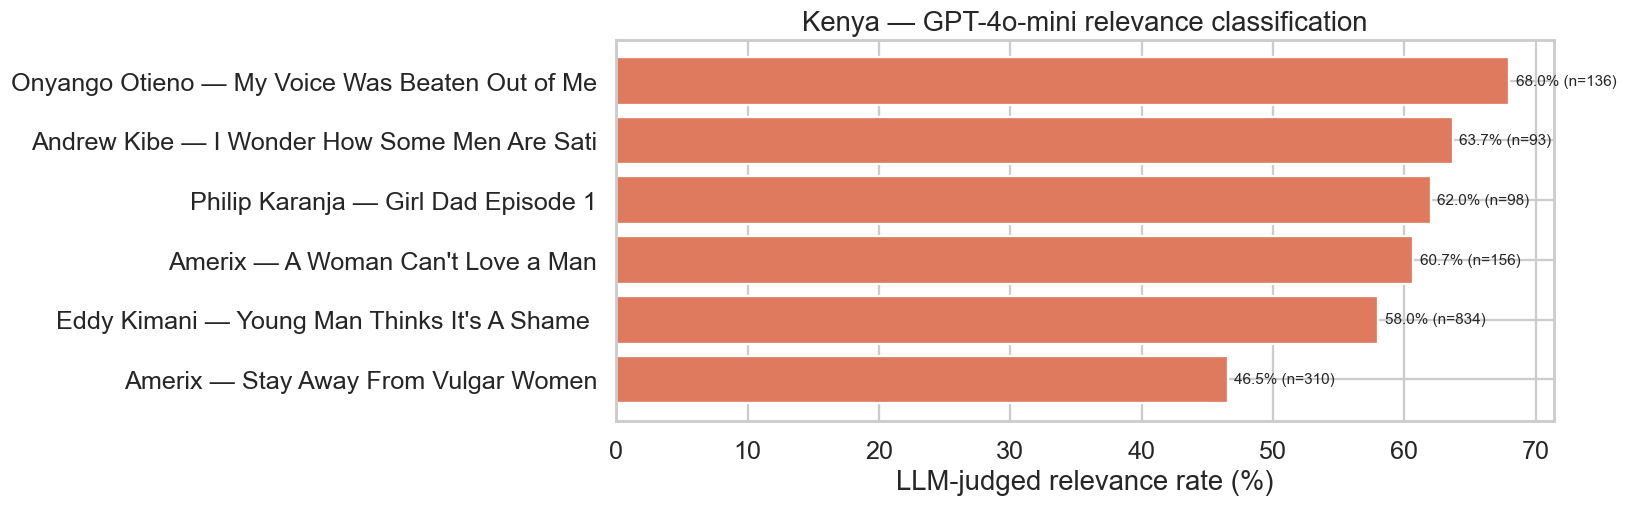

,creator,post,substantive,llm_relevant,llm_rate
0,Amerix,A Woman Can't Love a Man,257,156,0.607004
1,Amerix,Stay Away From Vulgar Women,666,310,0.465465
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,146,93,0.636986
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,1438,834,0.579972
4,Onyango Otieno,My Voice Was Beaten Out of Me,200,136,0.680000
5,Philip Karanja,Girl Dad Episode 1,158,98,0.620253


In [13]:
llm_summary = (sub.groupby(["creator", "post"])
                  .agg(substantive=("llm_relevant", "size"), llm_relevant=("llm_relevant", "sum"))
                  .reset_index())
llm_summary["llm_rate"] = llm_summary["llm_relevant"] / llm_summary["substantive"]

fig, ax = plt.subplots(figsize=(11, 4.5))
o = llm_summary.sort_values("llm_rate", ascending=True)
ax.barh(o["creator"] + " — " + o["post"].str.slice(0, 30), o["llm_rate"] * 100, color="#E07A5F")
ax.set_xlabel("LLM-judged relevance rate (%)")
ax.set_title("Kenya — GPT-4o-mini relevance classification")
for i, (r, n) in enumerate(zip(o["llm_rate"], o["llm_relevant"])):
    ax.text(r * 100 + 0.5, i, f"{r:.1%} (n={int(n)})", va="center", fontsize=10)
plt.savefig(PLOTS_DIR / "05_llm_relevance.png")
plt.show()
llm_summary


## 7 — Composite scoring + top-200 selection

In [14]:
sub["sim_scaled"] = sub.groupby("post")["sim_max"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
sub["score"] = (0.25 * sub["has_keyword"].astype(float)
                + 0.35 * sub["sim_scaled"]
                + 0.40 * sub["llm_relevant"].astype(float))

selected_frames = []
for (creator, post), g in sub.groupby(["creator", "post"]):
    # Only include LLM-relevant comments. If fewer than 200 are relevant, take all of them — never pad.
    eligible = g[g["llm_relevant"]].copy()
    top = eligible.sort_values("score", ascending=False).head(TARGET_PER_POST).copy()
    top["rank"] = range(1, len(top) + 1)
    selected_frames.append(top)

selected = pd.concat(selected_frames, ignore_index=True)
selection_summary = (selected.groupby(["creator", "post"])
                     .agg(selected=("rank", "size"), avg_score=("score", "mean"),
                          avg_sim=("sim_max", "mean"), kw_rate=("has_keyword", "mean"))
                     .reset_index())
selection_summary


,creator,post,selected,avg_score,avg_sim,kw_rate
0,Amerix,A Woman Can't Love a Man,156,0.689457,0.292862,0.525641
1,Amerix,Stay Away From Vulgar Women,200,0.677707,0.311738,0.395000
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,93,0.668048,0.305108,0.344086
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,200,0.694261,0.315071,0.600000
4,Onyango Otieno,My Voice Was Beaten Out of Me,136,0.681866,0.294161,0.411765
5,Philip Karanja,Girl Dad Episode 1,98,0.688418,0.321649,0.448980


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_71479/2702440811.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)


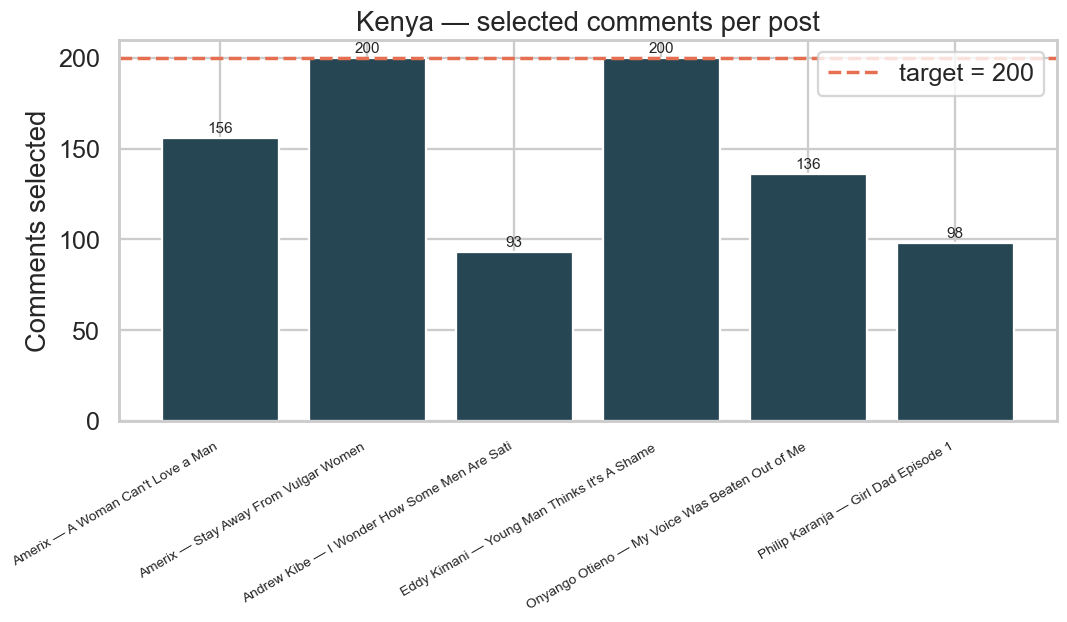

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
labels = selection_summary["creator"] + " — " + selection_summary["post"].str.slice(0, 30)
ax.bar(labels, selection_summary["selected"], color="#264653")
ax.axhline(TARGET_PER_POST, linestyle="--", color="#E76F51", label=f"target = {TARGET_PER_POST}")
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Comments selected")
ax.set_title("Kenya — selected comments per post")
for i, n in enumerate(selection_summary["selected"]):
    ax.text(i, n + 3, f"{int(n)}", ha="center", fontsize=10)
ax.legend()
plt.savefig(PLOTS_DIR / "06_selected_counts.png")
plt.show()


## 8 — Export (text column only)

In [16]:
def _safe(name):
    return re.sub(r"[^\w\- ]+", "", name).strip()


summary_rows = []
for (creator, post), g in selected.groupby(["creator", "post"]):
    creator_dir = OUTPUT_DIR / _safe(creator)
    creator_dir.mkdir(parents=True, exist_ok=True)
    out_path = creator_dir / f"{_safe(post)}.xlsx"
    out = pd.DataFrame({"text": g.sort_values("rank")["raw_text"].values})
    out.to_excel(out_path, index=False)
    summary_rows.append({"creator": creator, "post": post, "rows": len(out), "path": str(out_path.relative_to(ROOT))})

summary = pd.DataFrame(summary_rows)
summary.to_excel(OUTPUT_DIR / "_summary.xlsx", index=False)
print(f"Wrote {len(summary)} files to {OUTPUT_DIR}")
summary


Wrote 6 files to /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project/Topic Relevant Comments - Kenya


,creator,post,rows,path
0,Amerix,A Woman Can't Love a Man,156,Topic Relevant Comments - Kenya/Amerix/A Woman...
1,Amerix,Stay Away From Vulgar Women,200,Topic Relevant Comments - Kenya/Amerix/Stay Aw...
2,Andrew Kibe,I Wonder How Some Men Are Satisfied,93,Topic Relevant Comments - Kenya/Andrew Kibe/I ...
3,Eddy Kimani,Young Man Thinks It's A Shame Not Having A Car...,200,Topic Relevant Comments - Kenya/Eddy Kimani/Yo...
4,Onyango Otieno,My Voice Was Beaten Out of Me,136,Topic Relevant Comments - Kenya/Onyango Otieno...
5,Philip Karanja,Girl Dad Episode 1,98,Topic Relevant Comments - Kenya/Philip Karanja...


## 9 — Report-ready plots

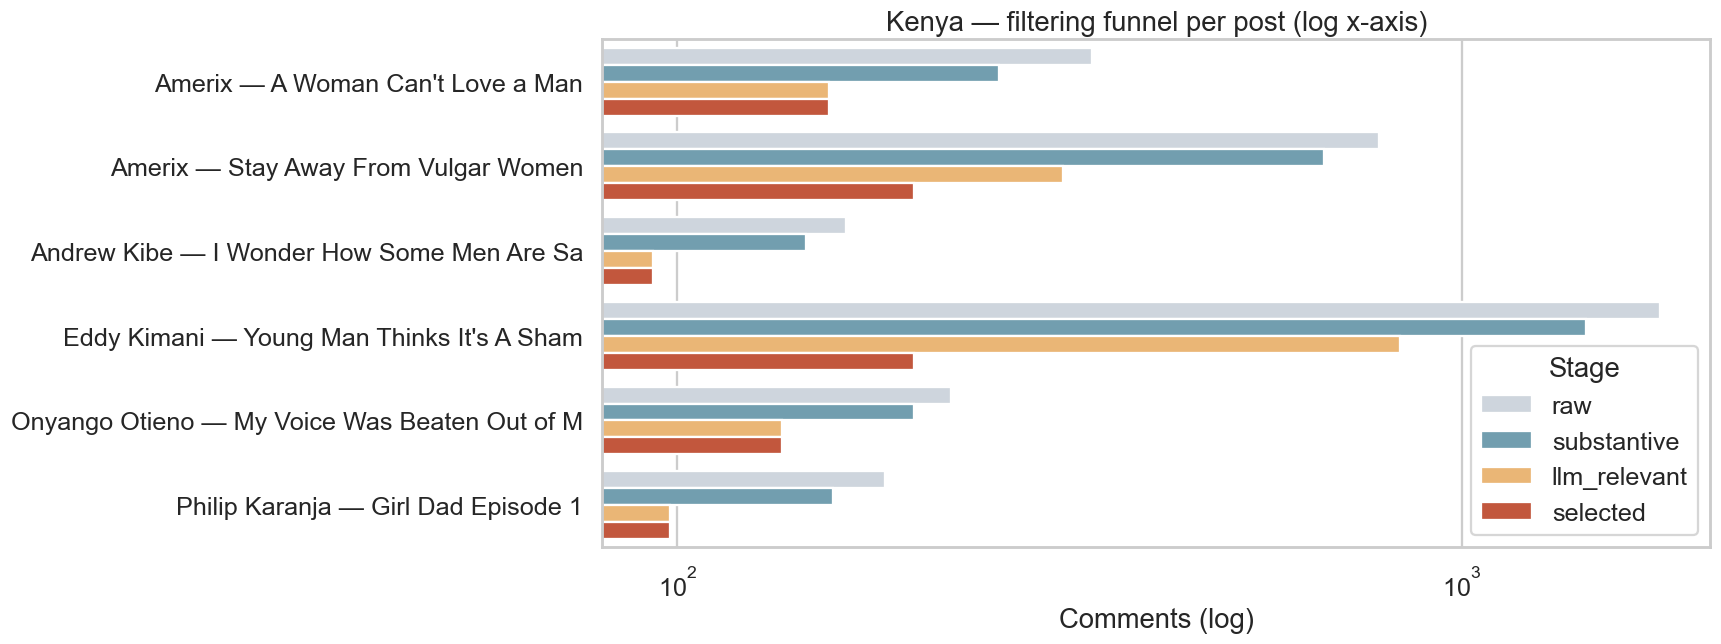

In [17]:
funnel = (raw_counts
    .merge(retention[["creator", "post", "substantive"]], on=["creator", "post"])
    .merge(llm_summary[["creator", "post", "llm_relevant"]], on=["creator", "post"])
    .merge(selection_summary[["creator", "post", "selected"]], on=["creator", "post"])
    .rename(columns={"raw_n": "raw"}))
funnel_melt = funnel.melt(id_vars=["creator", "post"],
                          value_vars=["raw", "substantive", "llm_relevant", "selected"],
                          var_name="stage", value_name="count")
funnel_melt["stage"] = pd.Categorical(funnel_melt["stage"],
                                       categories=["raw", "substantive", "llm_relevant", "selected"], ordered=True)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=funnel_melt, y=funnel_melt["creator"] + " — " + funnel_melt["post"].str.slice(0, 28),
            x="count", hue="stage", ax=ax, palette=["#CBD5E0", "#68A2B9", "#FDB863", "#D84A27"])
ax.set_xscale("log")
ax.set_title("Kenya — filtering funnel per post (log x-axis)")
ax.set_xlabel("Comments (log)")
ax.set_ylabel("")
ax.legend(title="Stage", loc="lower right")
plt.savefig(PLOTS_DIR / "07_funnel.png")
plt.show()


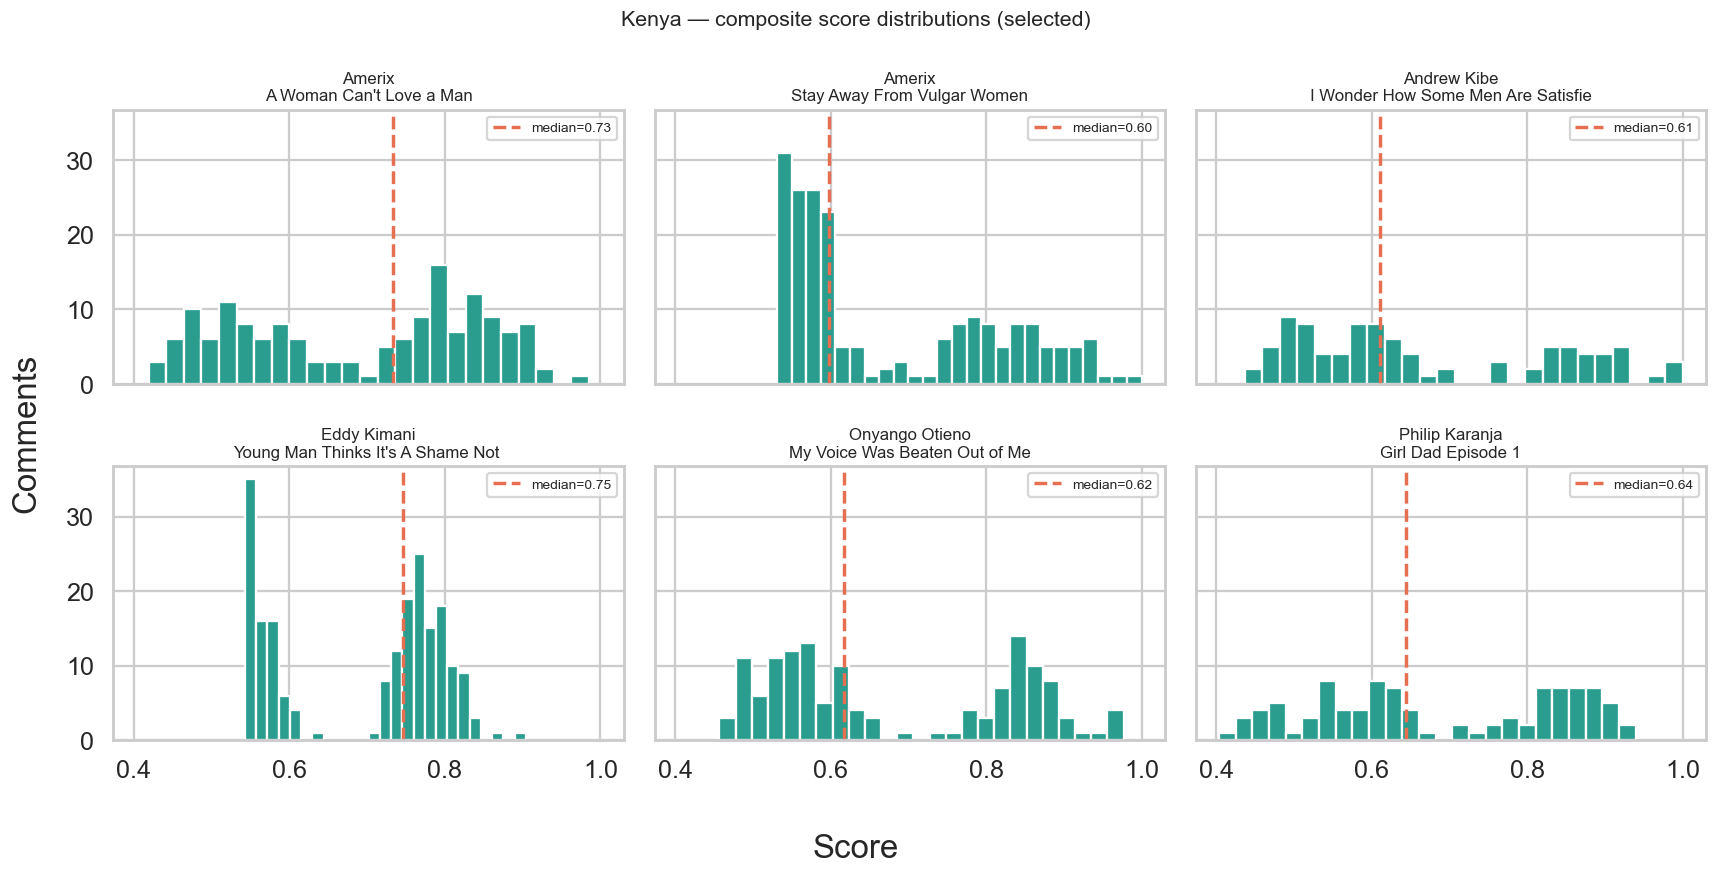

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, ((creator, post), g) in zip(axes.flat, selected.groupby(["creator", "post"])):
    ax.hist(g["score"], bins=25, color="#2A9D8F", edgecolor="white")
    ax.axvline(g["score"].median(), color="#E76F51", linestyle="--", label=f"median={g['score'].median():.2f}")
    ax.set_title(f"{creator}\n{post[:34]}", fontsize=11)
    ax.legend(fontsize=9)
fig.suptitle("Kenya — composite score distributions (selected)", fontsize=14)
fig.supxlabel("Score"); fig.supylabel("Comments")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_score_distributions.png")
plt.show()


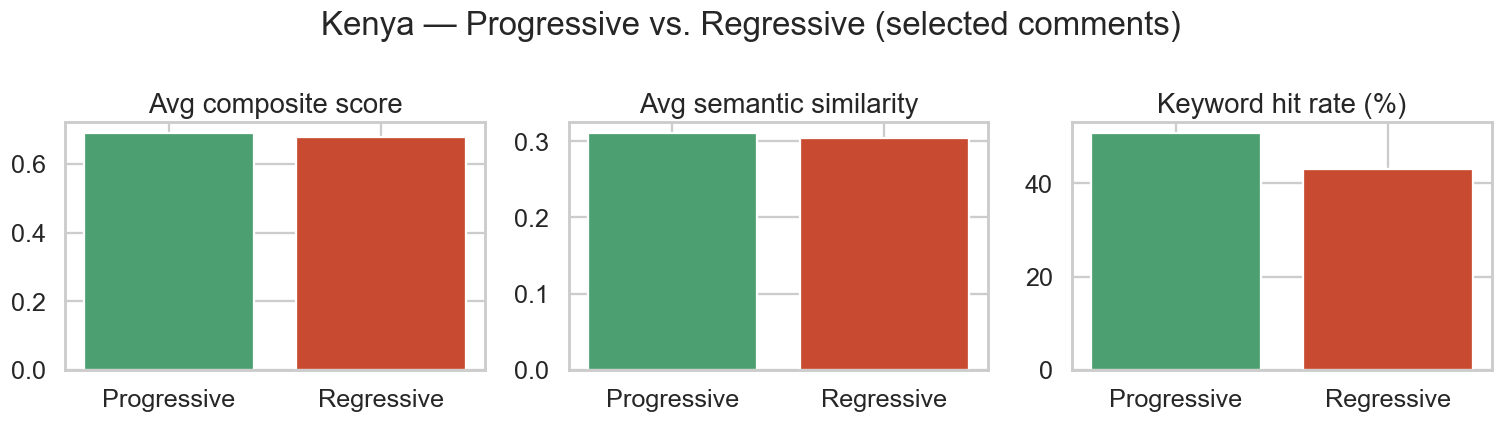

,orientation,n,avg_score,avg_sim,kw_rate,llm_rate
0,Progressive,434,0.689057,0.310004,0.506912,1.0
1,Regressive,449,0.679789,0.303806,0.429844,1.0


In [19]:
by_orient = selected.groupby("orientation").agg(
    n=("score", "size"), avg_score=("score", "mean"), avg_sim=("sim_max", "mean"),
    kw_rate=("has_keyword", "mean"), llm_rate=("llm_relevant", "mean")).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(by_orient["orientation"], by_orient["avg_score"], color=["#4C9F70", "#C84B31"])
axes[0].set_title("Avg composite score")
axes[1].bar(by_orient["orientation"], by_orient["avg_sim"], color=["#4C9F70", "#C84B31"])
axes[1].set_title("Avg semantic similarity")
axes[2].bar(by_orient["orientation"], by_orient["kw_rate"] * 100, color=["#4C9F70", "#C84B31"])
axes[2].set_title("Keyword hit rate (%)")
fig.suptitle("Kenya — Progressive vs. Regressive (selected comments)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_orientation_compare.png")
plt.show()
by_orient


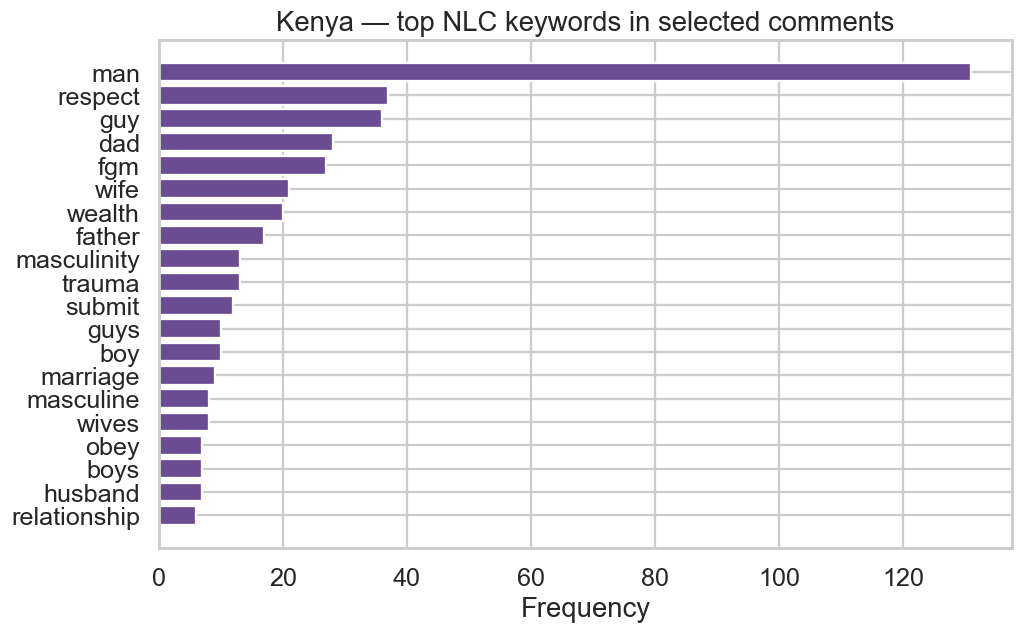

,keyword,count
0,man,131
1,respect,37
2,guy,36
3,dad,28
4,fgm,27
5,wife,21
6,wealth,20
7,father,17
8,masculinity,13
9,trauma,13


In [20]:
from collections import Counter
kw_counter = Counter()
for hits in selected["keyword_hits"]:
    kw_counter.update(hits)
top_kw = pd.DataFrame(kw_counter.most_common(20), columns=["keyword", "count"])
if len(top_kw):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_kw["keyword"][::-1], top_kw["count"][::-1], color="#6A4C93")
    ax.set_title("Kenya — top NLC keywords in selected comments")
    ax.set_xlabel("Frequency")
    plt.savefig(PLOTS_DIR / "10_top_keywords.png")
    plt.show()
top_kw


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_71479/1986427205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected, y=selected["creator"] + " — " + selected["post"].str.slice(0, 28),


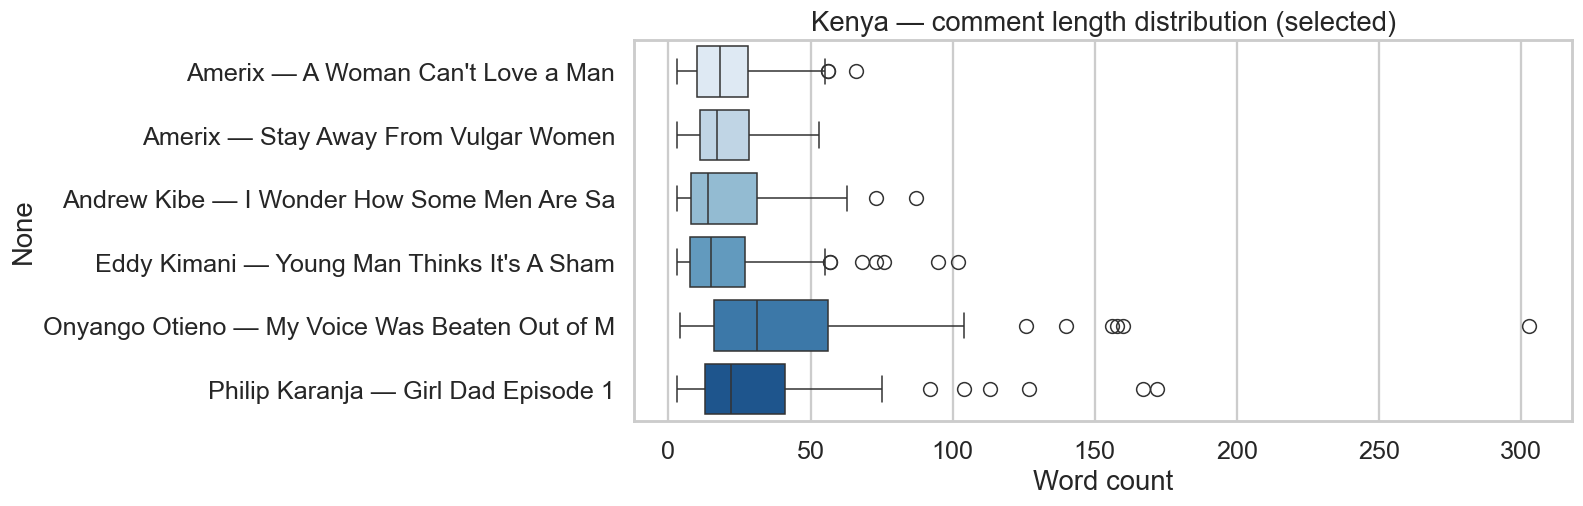

In [21]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=selected, y=selected["creator"] + " — " + selected["post"].str.slice(0, 28),
            x="n_words", ax=ax, palette="Blues")
ax.set_xlabel("Word count")
ax.set_title("Kenya — comment length distribution (selected)")
plt.savefig(PLOTS_DIR / "11_length_distribution.png")
plt.show()


## Notes

- Source: `Kenya Audience Comments/` (flat layout, mixed platforms).
- OP detection is platform-aware — X via URL, IG via `ownerUsername`, TikTok via `uniqueId`, YouTube via `author`.
- Lexicon: NLC Kenya sheet (295 terms across Swahili, Sheng, Gikuyu, English).
- Any post with fewer than 200 raw comments caps at its available volume (flagged in the selection plot).
- Caches in `temp/audience_analysis_kenya/`. Delete to re-compute.
- Output: `Topic Relevant Comments - Kenya/<Creator>/<Post>.xlsx` — text column only.
